In [40]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import classification_report, f1_score

import warnings
warnings.filterwarnings('ignore')


## 1: Load and Preprocess Data

In [41]:
# Load your fully feature-engineered dataset

df = pd.read_csv("feature_engineering/data_with_new_features_v2.csv")
participant_col_name = 'participant'

# df = pd.read_csv("../data_cleaning/data/imputed_data.csv")
# participant_col_name = 'person'


In [43]:
# Exclude non-numeric columns
exclude_cols = [participant_col_name, 'timestamp', 'genre']
numeric_cols = df.drop(columns=exclude_cols).select_dtypes(include=[np.number]).columns.tolist()

# Global normalization
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [44]:
# Encode other categorical columns (if any, excluding participant/timestamp/genre)
categorical_cols = df.select_dtypes(include=['object']).columns.difference([participant_col_name, 'timestamp', 'genre'])

for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Encode the target variable 'genre'
genre_label_encoder = LabelEncoder()
df['genre_encoded'] = genre_label_encoder.fit_transform(df['genre'])


## 2. Train/Val/Test Split by Participants

In [45]:
# Split Clara for test only
test_df = df[df[participant_col_name] == 'clara'].copy()

# Combine Kenji and Aimen data
train_val_df = df[df[participant_col_name].isin(['kenji', 'aimen'])].copy()

# Stratified split into train (80%) and val (20%) from Kenji + Aimen
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2,
    stratify=train_val_df['genre_encoded'],
    random_state=42
)

# Final test set is Clara
final_test_df = test_df.copy()

In [46]:
train_df

,timestamp,participant,heart_rate,x_coordinate,y_coordinate,pupil_diameter_mm,iris_diameter_mm,pupil_iris_ratio,head_displacement,head_velocity,...,pupil_iris_ratio_high_high,pupil_iris_ratio_high_normal,pupil_iris_ratio_low_high,pupil_iris_ratio_low_low,pupil_iris_ratio_low_normal,pupil_iris_ratio_normal_high,pupil_iris_ratio_normal_low,pupil_iris_ratio_normal_normal,genre,genre_encoded
7541,2025-06-12 09:59:01,aimen,0.188650,-0.871654,-0.435067,-0.764484,0.0,-0.764484,-0.361799,-0.326551,...,-1.502474,-0.861208,-1.677462,1.670781,-0.621492,-0.808083,-0.703489,-1.187135,comedy,0
756,2025-06-05 16:50:11,kenji,-1.467929,-0.816592,-1.156817,-0.469290,0.0,-0.469290,1.783269,1.105794,...,-0.095467,-0.908566,0.596139,-0.719958,-1.093804,-0.953164,-1.034909,-0.578116,comedy,0
8622,2025-06-12 10:20:58,aimen,0.143904,-0.834606,-1.332525,0.862913,0.0,0.862913,0.878323,1.400208,...,-1.502474,-0.861208,-1.677462,1.670781,-0.621492,-0.808083,-0.703489,-1.187135,horror,2
8972,2025-06-12 10:26:55,aimen,0.765005,0.159560,-1.751811,0.209050,0.0,0.209050,-0.449506,-0.448676,...,-1.502474,-0.861208,-1.677462,1.670781,-0.621492,-0.808083,-0.703489,-1.187135,horror,2
2671,2025-06-05 18:23:31,kenji,0.131785,-0.987696,-0.742166,1.633319,0.0,1.633319,3.261611,2.135024,...,-0.095467,-0.908566,0.596139,-0.719958,-1.093804,-0.953164,-1.034909,-0.578116,horror,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7267,2025-06-12 09:29:52,aimen,1.998117,-0.915745,-0.179799,-1.072893,0.0,-1.072893,-0.436315,-0.430308,...,-1.502474,-0.861208,-1.677462,1.670781,-0.621492,-0.808083,-0.703489,-1.187135,documentary,1
1373,2025-06-05 17:27:13,kenji,-2.134476,-1.008583,-0.542195,-0.471563,0.0,-0.471563,-0.441265,-0.444851,...,-0.095467,-0.908566,0.596139,-0.719958,-1.093804,-0.953164,-1.034909,-0.578116,documentary,1
1274,2025-06-05 17:23:53,kenji,-1.601238,-1.059040,-0.562721,-0.417095,0.0,-0.417095,-0.427222,-0.438333,...,-0.095467,-0.908566,0.596139,-0.719958,-1.093804,-0.953164,-1.034909,-0.578116,documentary,1
8274,2025-06-12 10:15:10,aimen,-0.134834,-1.017948,-1.372065,1.345109,0.0,1.345109,-0.398686,-0.377913,...,-1.502474,-0.861208,-1.677462,1.670781,-0.621492,-0.808083,-0.703489,-1.187135,horror,2


In [47]:
numeric_cols

['heart_rate',
 'x_coordinate',
 'y_coordinate',
 'pupil_diameter_mm',
 'iris_diameter_mm',
 'pupil_iris_ratio',
 'head_displacement',
 'head_velocity',
 'head_direction_change_rate',
 'head_stability',
 'centered_x',
 'centered_y',
 'td_heart_rate_mean',
 'td_heart_rate_std',
 'td_heart_rate_min',
 'td_heart_rate_max',
 'td_heart_rate_range',
 'td_heart_rate_slope',
 'td_heart_rate_mean_abs_change',
 'td_heart_rate_second_order_diff_mean',
 'td_centered_x_mean',
 'td_centered_x_std',
 'td_centered_x_min',
 'td_centered_x_max',
 'td_centered_x_range',
 'td_centered_x_slope',
 'td_centered_x_mean_abs_change',
 'td_centered_x_second_order_diff_mean',
 'td_centered_y_mean',
 'td_centered_y_std',
 'td_centered_y_min',
 'td_centered_y_max',
 'td_centered_y_range',
 'td_centered_y_slope',
 'td_centered_y_mean_abs_change',
 'td_centered_y_second_order_diff_mean',
 'td_pupil_diameter_mm_mean',
 'td_pupil_diameter_mm_std',
 'td_pupil_diameter_mm_min',
 'td_pupil_diameter_mm_max',
 'td_pupil_dia

In [48]:
# define features and labels
X_train = train_df[numeric_cols]
y_train = train_df['genre_encoded']

X_val = val_df[numeric_cols]
y_val = val_df['genre_encoded']

X_test = final_test_df[numeric_cols]
y_test = final_test_df['genre_encoded']

## 3. RFECV for Feature Selection

In [49]:
rf = RandomForestClassifier(n_estimators=75, max_depth=25, min_samples_split=15, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(estimator=rf, step=1, cv=cv, scoring='f1_weighted', n_jobs=-1)
rfecv.fit(X_train, y_train)

# Reduce features
X_train_sel = rfecv.transform(X_train)
X_val_sel = rfecv.transform(X_val)
X_test_sel = rfecv.transform(X_test)


In [50]:
feature_ranks = pd.DataFrame({
    'feature': X_train.columns,
    'rank': rfecv.ranking_
}).sort_values(by='rank')

print(feature_ranks)

                               feature  rank
0                           heart_rate     1
89       pupil_iris_ratio_fft_centroid     1
88  pupil_iris_ratio_fft_dominant_freq     1
87        pupil_iris_ratio_fft_max_amp     1
86  iris_diameter_mm_fft_band_0.25_0.5     1
..                                 ...   ...
45             td_iris_diameter_mm_std     4
73       pupil_diameter_mm_fft_max_amp     5
49           td_iris_diameter_mm_slope     6
67        heart_rate_fft_dominant_freq     7
46             td_iris_diameter_mm_min     8

[122 rows x 2 columns]


## 4. Train and Evaluate Final Random Forest

In [51]:
rf_final = RandomForestClassifier(n_estimators=75, max_depth=25, min_samples_split=15, random_state=42)
rf_final.fit(X_train_sel, y_train)

# Validation
val_preds = rf_final.predict(X_val_sel)
print("Validation Report:\n", classification_report(y_val, val_preds))

# Test
test_preds = rf_final.predict(X_test_sel)
print("Test Report:\n", classification_report(y_test, test_preds))

Validation Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       324
           1       1.00      1.00      1.00       296
           2       0.99      0.99      0.99       427

    accuracy                           0.99      1047
   macro avg       0.99      0.99      0.99      1047
weighted avg       0.99      0.99      0.99      1047

Test Report:
               precision    recall  f1-score   support

           0       0.31      0.13      0.18      1340
           1       0.40      0.87      0.55      1560
           2       0.73      0.08      0.15      1212

    accuracy                           0.40      4112
   macro avg       0.48      0.36      0.29      4112
weighted avg       0.47      0.40      0.31      4112



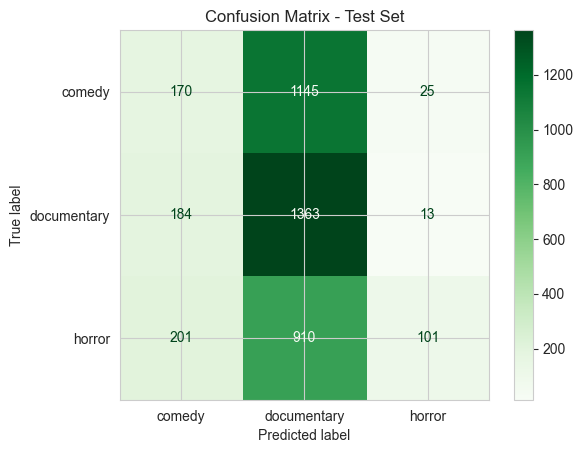

In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Test confusion matrix
test_cm = confusion_matrix(y_test, test_preds)
test_disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=genre_label_encoder.classes_)
test_disp.plot(cmap='Greens')
plt.title("Confusion Matrix - Test Set")
plt.show()
